# Cross-Lingual Entity Analysis for Idioms

## Summary

### Goal
Investigate how the **same entities** convey **different cultural meanings** across English and Chinese idioms (e.g., "dragon/龙" carries power/evil in English vs. auspiciousness/imperial authority in Chinese).

### What Was Built
**Main script** (`cross_lingual_same_entity_diff_meaning.py`) with a multi-step pipeline orchestrated by `run_cross_lingual_analysis.sh`.

### Pipeline (as run)

**Stage 1 -- Entity Translation & Filtering:**

1. Extract **top-500** most frequent entities from each language's idiom dataset
2. **GPT-5.2 translation** (Prompt 1 -- high-recall translation): For each entity, generate ALL possible translations to the other language. EN->ZH translations are constrained to **1-2 characters** to match typical entity lengths in 4-character Chinese idioms (e.g., "water" -> ["水", "江", "河", "海"])
3. **Embedding expansion**: Expand each translation set with similar entities from the target language's full entity dictionary using Qwen3-Embedding-0.6B (cosine similarity >= **0.95**)
4. **GPT-5.2 semantic filter** (Prompt 2 -- synonym verification): Remove non-synonym translations from the expanded set. The LLM rejects hypernyms ("animal" for "dog"), hyponyms ("puppy" for "dog"), related-but-different concepts ("cat" for "dog"), associated concepts ("bone" for "dog"), and part-whole relations ("leg" for "body") -- keeping only true translation equivalents
5. Build entity clusters and match to idioms in the target language (exact entity match + substring search, up to **20 idioms per entity**)

**Stage 2 -- Cultural Analysis:**

6. **GPT-5.2 cultural analysis** (Prompt 3 -- structured comparison): For each cross-lingual entity pair, analyze the sampled idioms and produce a structured JSON with: `english_primary_meanings`, `chinese_primary_meanings`, `shared_meanings`, `english_unique_aspects`, `chinese_unique_aspects`, `cultural_explanation`, and `summary`

### Key Parameters (defaults from `run_cross_lingual_analysis.sh`)
| Parameter | Value | Description |
|-----------|-------|-------------|
| `--top_k` | 500 | Number of most frequent entities per language |
| `--entity_expand_threshold` | 0.95 | Cosine similarity threshold for embedding expansion |
| `--use_embeddings` | enabled | Use Qwen3-Embedding-0.6B for entity cluster expansion |
| `--use_semantic_filter` | enabled | Use GPT-5.2 to filter non-synonym translations |
| `--max_idioms` | 20 | Max idioms sampled per entity pair |
| `--model` | gpt-5.2-chat-latest | LLM for translation, filtering, and analysis |

### How to Run
```bash
# Run both stages (default)
./run_cross_lingual_analysis.sh

# Run only translation + filtering (Stage 1)
./run_cross_lingual_analysis.sh --stage 1

# Run only cultural analysis using existing translations (Stage 2)
./run_cross_lingual_analysis.sh --stage 2
```

### Output Files

| File | Description |
|------|-------------|
| `top_entities_en.json` | Top-K most frequent English entities |
| `top_entities_zh.json` | Top-K most frequent Chinese entities |
| `translations_en_to_zh.json` | LLM-generated translations (EN -> ZH) |
| `translations_zh_to_en.json` | LLM-generated translations (ZH -> EN) |
| `translations_semantic_filtered.json` | Semantic-filtered translations (only with `--use_semantic_filter`) |
| `entity_cluster_pairs.json` | Cross-lingual entity cluster pairs (with `--use_embeddings`) |
| `entity_pairs.json` | Cross-lingual entity pairs (without embeddings, legacy mode) |
| `cultural_analysis_clusters.json` / `.jsonl` | Final analysis with cultural analysis (with embeddings) |
| `cultural_analysis_results.json` / `.jsonl` | Final analysis (legacy mode, without embeddings) |

Each cultural analysis result contains: `english_primary_meanings`, `chinese_primary_meanings`, `shared_meanings`, `english_unique_aspects`, `chinese_unique_aspects`, `cultural_explanation`, and `summary`.

## Notebook: Explore Results

This notebook loads the analysis outputs and provides interactive exploration:
1. **Top entities** -- most frequent entities in each language
2. **Entity translations** -- high-recall LLM translations (EN->ZH, ZH->EN)
3. **Cross-lingual entity pairs** -- matched entity pairs with idiom counts
4. **Cultural analysis** -- GPT-5.2's structured analysis of meaning differences per entity
5. **Summary statistics** -- aggregated cultural themes across all pairs
6. **Interactive exploration** -- search for specific entities (e.g., `explore_entity("dragon", cultural_results)`)
7. **CSV export** -- flattened summary for downstream analysis

In [1]:
%load_ext autoreload
%autoreload 2

import json
import os
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np
from IPython.display import display, HTML, Markdown

Bad value in file '/home/jiaruil5/.config/matplotlib/matplotlibrc', line 18 ("axes.prop_cycle : cycler(color=['#FFAF00','#F46920','#F53255','#F857C1','#29BDFD','#00CBBF','#01C159','#9DCA1C']) #hex colours"): Key axes.prop_cycle: "cycler(color=['" is not a valid cycler construction: unterminated string literal (detected at line 1) (<unknown>, line 1)


In [2]:
# Setup paths
DATA_DIR = "/home/jiaruil5/culture_pretrain/CultureInFigurativeLanguage/culture/data/idioms"
ANALYSIS_DIR = os.path.join(DATA_DIR, "cross_lingual_analysis")

EN_IDIOMS_FILE = os.path.join(DATA_DIR, "en/idioms_merged_llm_formatted.jsonl")
ZH_IDIOMS_FILE = os.path.join(DATA_DIR, "zh/idioms_merged_llm_formatted.jsonl")

# Check if analysis has been run
if os.path.exists(ANALYSIS_DIR):
    print(f"Analysis directory found: {ANALYSIS_DIR}")
    print("Files:", os.listdir(ANALYSIS_DIR))
else:
    print("Analysis not yet run. Please run the analysis script first:")
    print("bash run_cross_lingual_analysis.sh")

Analysis directory found: /home/jiaruil5/culture_pretrain/CultureInFigurativeLanguage/culture/data/idioms/cross_lingual_analysis
Files: ['cultural_analysis_summary.csv', 'cultural_analysis_clusters.jsonl', 'translations_zh_to_en.json', 'entity_cluster_pairs.json', 'translations_en_to_zh.json', 'cultural_analysis_results.jsonl', 'cultural_analysis_results.json', 'top_entities_en.json', 'cultural_analysis_clusters.json', 'translations_semantic_filtered.json', 'entity_pairs.json', 'top_entities_zh.json']


## 1. Load and Explore Top Entities

In [3]:
# Load idioms data
def load_jsonl(file_path):
    data = []
    with open(file_path, 'r', encoding='utf8') as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line))
    return data

def load_json(file_path):
    with open(file_path, 'r', encoding='utf8') as f:
        return json.load(f)

# Load idioms
en_idioms = load_jsonl(EN_IDIOMS_FILE)
zh_idioms = load_jsonl(ZH_IDIOMS_FILE)

print(f"Loaded {len(en_idioms)} English idioms")
print(f"Loaded {len(zh_idioms)} Chinese idioms")

Loaded 32080 English idioms
Loaded 31155 Chinese idioms


In [4]:
# Extract entity counters
def get_entity_counter(idioms_data):
    counter = Counter()
    for item in idioms_data:
        if item.get('output'):
            entities = item['output'].get('entities', [])
            for e in entities:
                counter[e] += 1
    return counter

en_counter = get_entity_counter(en_idioms)
zh_counter = get_entity_counter(zh_idioms)

print(f"Unique entities in English: {len(en_counter)}")
print(f"Unique entities in Chinese: {len(zh_counter)}")

Unique entities in English: 5526
Unique entities in Chinese: 13304


In [5]:
# Show top 20 entities for each language
print("Top 20 English entities:")
for i, (entity, count) in enumerate(en_counter.most_common(20), 1):
    print(f"  {i:2d}. {entity}: {count}")

print("\nTop 20 Chinese entities:")
for i, (entity, count) in enumerate(zh_counter.most_common(20), 1):
    print(f"  {i:2d}. {entity}: {count}")

Top 20 English entities:
   1. something: 2984
   2. someone: 2193
   3. thing: 486
   4. person: 349
   5. place: 322
   6. time: 253
   7. head: 242
   8. hand: 235
   9. eye: 184
  10. way: 180
  11. animal: 161
  12. foot: 146
  13. day: 135
  14. word: 131
  15. back: 129
  16. heart: 129
  17. mind: 119
  18. man: 119
  19. face: 114
  20. line: 107

Top 20 Chinese entities:
   1. 心: 689
   2. 人: 552
   3. 天: 500
   4. 风: 465
   5. 地: 307
   6. 言: 302
   7. 日: 277
   8. 水: 252
   9. 马: 250
  10. 目: 248
  11. 山: 232
  12. 口: 227
  13. 云: 221
  14. 虎: 210
  15. 龙: 206
  16. 头: 194
  17. 气: 186
  18. 手: 184
  19. 雨: 182
  20. 身: 176


## 2. Load Cross-Lingual Analysis Results

In [6]:
# Load analysis results if available
if os.path.exists(ANALYSIS_DIR):
    # Load top entities
    try:
        top_en = load_json(os.path.join(ANALYSIS_DIR, "top_entities_en.json"))
        top_zh = load_json(os.path.join(ANALYSIS_DIR, "top_entities_zh.json"))
        print(f"Loaded {len(top_en)} top English entities")
        print(f"Loaded {len(top_zh)} top Chinese entities")
    except FileNotFoundError:
        print("Top entities files not found")
        top_en, top_zh = [], []
    
    # Load translations
    try:
        en_to_zh_trans = load_json(os.path.join(ANALYSIS_DIR, "translations_en_to_zh.json"))
        zh_to_en_trans = load_json(os.path.join(ANALYSIS_DIR, "translations_zh_to_en.json"))
        print(f"Loaded {len(en_to_zh_trans)} EN->ZH translations")
        print(f"Loaded {len(zh_to_en_trans)} ZH->EN translations")
    except FileNotFoundError:
        print("Translation files not found")
        en_to_zh_trans, zh_to_en_trans = {}, {}
    
    # Load entity pairs
    try:
        entity_pairs = load_json(os.path.join(ANALYSIS_DIR, "entity_pairs.json"))
        print(f"Loaded {len(entity_pairs)} cross-lingual entity pairs")
    except FileNotFoundError:
        print("Entity pairs file not found")
        entity_pairs = []
    
    # Load cultural analysis results
    try:
        cultural_results = load_json(os.path.join(ANALYSIS_DIR, "cultural_analysis_results.json"))
        print(f"Loaded {len(cultural_results)} cultural analysis results")
    except FileNotFoundError:
        print("Cultural analysis results not found")
        cultural_results = []
else:
    print("Analysis directory not found. Please run the analysis first.")

Loaded 500 top English entities
Loaded 500 top Chinese entities
Loaded 500 EN->ZH translations
Loaded 500 ZH->EN translations
Loaded 369 cross-lingual entity pairs
Loaded 369 cultural analysis results


## 3. Explore Entity Translations

In [7]:
# Show sample translations EN -> ZH
if en_to_zh_trans:
    print("Sample English to Chinese translations (high recall):")
    for i, (entity, translations) in enumerate(list(en_to_zh_trans.items())[:10]):
        print(f"  {entity} -> {translations}")

Sample English to Chinese translations (high recall):
  something -> ['物', '事', '东西', '事物', '物件', '物什', '玩意', '某物', '某事', '一物', '一事', '此物', '彼物', '何物', '万物', '凡物']
  someone -> ['人', '众', '众人', '他人', '别人', '旁人', '世人', '凡人', '小人', '某人', '人家', '人物', '人士', '人等', '人氏', '人们']
  thing -> ['物', '事', '东西', '物件', '物品', '事物', '事情', '件', '器', '器物', '品', '货', '宝', '万物', '物什']
  person -> ['人', '人物', '人民', '众人', '他人', '别人', '世人', '凡人', '常人', '众生', '人类', '人士', '小人', '君子']
  place -> ['地', '处', '所', '位', '席', '方', '场', '座', '境', '域', '地方', '地点', '位置', '位子', '场所', '场地', '席位', '地盘', '地界', '地段', '地位', '地步', '场面', '本地', '当地']
  time -> ['时', '时间', '光', '光阴', '时光', '岁', '岁月', '年', '年华', '月', '日', '日月', '昼', '夜', '晨', '夕', '朝', '暮', '春', '夏', '秋', '冬', '期', '刻', '分', '秒', '旬', '载', '世', '代', '纪', '朝代', '时辰', '今', '古', '午', '晚']
  head -> ['头', '首', '脑', '头脑', '面', '颜', '额', '顶', '头顶', '头颅', '首领', '头面']
  hand -> ['手', '掌', '手心', '掌心', '腕', '指', '拳', '爪', '臂', '手臂', '手腕', '手足']
  eye -> ['眼', '目', '眸', '瞳',

In [8]:
# Show sample translations ZH -> EN
if zh_to_en_trans:
    print("Sample Chinese to English translations (high recall):")
    for i, (entity, translations) in enumerate(list(zh_to_en_trans.items())[:10]):
        print(f"  {entity} -> {translations}")

Sample Chinese to English translations (high recall):
  心 -> ['heart', 'mind', 'soul', 'spirit', 'core', 'center', 'bosom', 'breast', 'conscience', 'psyche', 'will', 'mood', 'feelings', 'emotions', 'inner self', 'self', 'guts', 'courage', 'temper', 'head']
  人 -> ['person', 'people', 'human', 'human being', 'man', 'men', 'individual', 'folk', 'mortal', 'guy']
  天 -> ['sky', 'heaven', 'heavens', 'firmament', 'day', 'days', 'nature', 'fate', 'destiny', 'providence', 'paradise', 'weather']
  风 -> ['wind', 'winds', 'breeze', 'breezes', 'gust', 'gusts', 'gale', 'gales', 'storm', 'storms', 'whirlwind', 'zephyr', 'draft', 'air', 'weather', 'fashion', 'style', 'trend', 'custom']
  地 -> ['earth', 'ground', 'land', 'soil', 'terrain', 'floor', 'place', 'field', 'territory', 'world']
  言 -> ['word', 'words', 'speech', 'saying', 'sayings', 'utterance', 'remark', 'comment', 'statement', 'talk', 'language', 'voice', 'tongue', 'message', 'promise', 'pledge', 'oath']
  日 -> ['sun', 'day', 'date', 'dayt

## 4. Analyze Cross-Lingual Entity Pairs

In [9]:
# Create DataFrame for entity pairs
if entity_pairs:
    pairs_df = pd.DataFrame([
        {
            'entity_en': p['entity_en'],
            'entity_zh': p['entity_zh'],
            'direction': p['translation_direction'],
            'num_en_idioms': p.get('num_en_idioms', len(p.get('idioms_en', []))),
            'num_zh_idioms': p.get('num_zh_idioms', len(p.get('idioms_zh', [])))
        }
        for p in entity_pairs
    ])
    
    print(f"Total entity pairs: {len(pairs_df)}")
    print(f"\nPairs from EN->ZH direction: {len(pairs_df[pairs_df['direction'] == 'en_to_zh'])}")
    print(f"Pairs from ZH->EN direction: {len(pairs_df[pairs_df['direction'] == 'zh_to_en'])}")
    
    display(pairs_df.head(20))

Total entity pairs: 369

Pairs from EN->ZH direction: 200
Pairs from ZH->EN direction: 169


,entity_en,entity_zh,direction,num_en_idioms,num_zh_idioms
0,something,货色,en_to_zh,20,20
1,someone,人,en_to_zh,20,20
2,thing,宝,en_to_zh,20,20
3,person,人群,en_to_zh,20,20
4,place,域,en_to_zh,20,20
5,time,年,en_to_zh,20,20
6,head,顶,en_to_zh,20,20
7,hand,手臂,en_to_zh,20,20
8,eye,睛,en_to_zh,20,20
9,way,途,en_to_zh,20,20


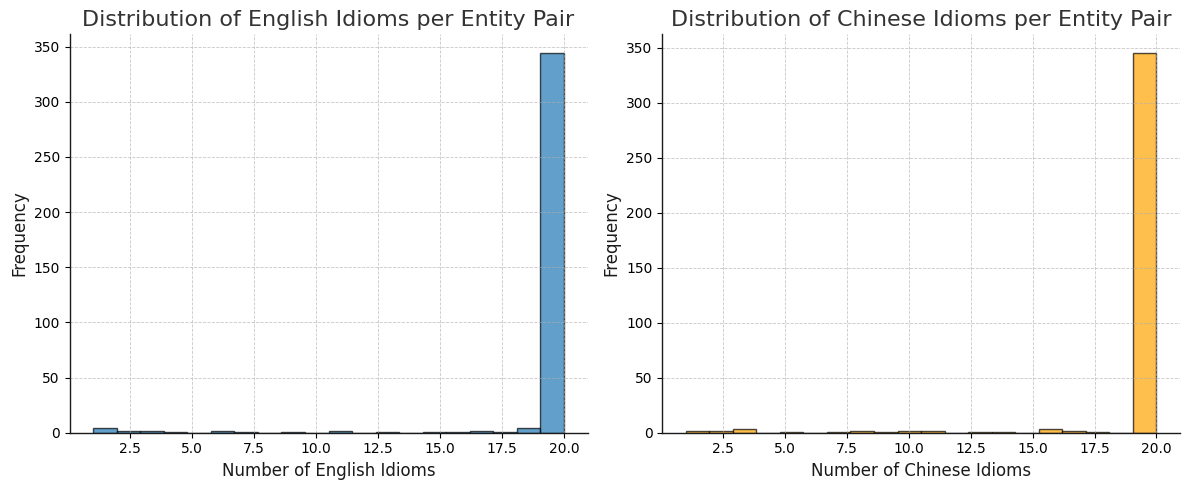

In [10]:
# Visualize distribution of idiom counts
if entity_pairs:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].hist(pairs_df['num_en_idioms'], bins=20, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Number of English Idioms')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Distribution of English Idioms per Entity Pair')
    
    axes[1].hist(pairs_df['num_zh_idioms'], bins=20, edgecolor='black', alpha=0.7, color='orange')
    axes[1].set_xlabel('Number of Chinese Idioms')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Distribution of Chinese Idioms per Entity Pair')
    
    plt.tight_layout()
    plt.show()

## 5. Cultural Analysis Deep Dive

In [11]:
def display_cultural_analysis(result):
    """Display a single cultural analysis result in a readable format."""
    print("=" * 80)
    print(f"Entity: {result['entity_en']} / {result['entity_zh']}")
    print(f"Translation direction: {result['translation_direction']}")
    print("=" * 80)
    
    # Show sample idioms
    print("\n--- English Idioms (sample) ---")
    for idiom in result.get('idioms_en', [])[:5]:
        print(f"  - {idiom['idiom']}")
        if idiom.get('figurative_meanings'):
            print(f"    Meaning: {idiom['figurative_meanings'][0][:100]}..." if len(idiom['figurative_meanings'][0]) > 100 else f"    Meaning: {idiom['figurative_meanings'][0]}")
    
    print("\n--- Chinese Idioms (sample) ---")
    for idiom in result.get('idioms_zh', [])[:5]:
        print(f"  - {idiom['idiom']}")
        if idiom.get('figurative_meanings'):
            print(f"    Meaning: {idiom['figurative_meanings'][0][:100]}..." if len(idiom['figurative_meanings'][0]) > 100 else f"    Meaning: {idiom['figurative_meanings'][0]}")
    
    # Parse and display cultural analysis
    analysis = result.get('cultural_analysis', '')
    if analysis:
        print("\n--- Cultural Analysis ---")
        try:
            # Try to parse as JSON
            if isinstance(analysis, str):
                # Extract JSON from markdown code blocks if present
                import re
                json_match = re.search(r'```(?:json)?\s*\n?({[^`]+})\s*\n?```', analysis, re.DOTALL)
                if json_match:
                    analysis_dict = json.loads(json_match.group(1))
                else:
                    analysis_dict = json.loads(analysis)
            else:
                analysis_dict = analysis
            
            print(f"\nEnglish primary meanings: {analysis_dict.get('english_primary_meanings', [])}")
            print(f"Chinese primary meanings: {analysis_dict.get('chinese_primary_meanings', [])}")
            print(f"\nShared meanings: {analysis_dict.get('shared_meanings', [])}")
            print(f"\nEnglish unique aspects: {analysis_dict.get('english_unique_aspects', [])}")
            print(f"Chinese unique aspects: {analysis_dict.get('chinese_unique_aspects', [])}")
            print(f"\nCultural explanation: {analysis_dict.get('cultural_explanation', '')}")
            print(f"\nSummary: {analysis_dict.get('summary', '')}")
        except (json.JSONDecodeError, TypeError):
            print(analysis[:1000] if len(analysis) > 1000 else analysis)
    
    print("\n")

In [12]:
# Display first few cultural analysis results
if cultural_results:
    print(f"Showing first 5 of {len(cultural_results)} cultural analysis results:\n")
    for result in cultural_results[:5]:
        display_cultural_analysis(result)

Showing first 5 of 369 cultural analysis results:

Entity: something / 货色
Translation direction: en_to_zh

--- English Idioms (sample) ---
  - (It) just goes to show (you) (something).
    Meaning: That incident or story has an important moral or message.
  - (I’d be) happy to (do something).
  - *access to someone or something
  - *accustomed to doing something
    Meaning: used to someone or something; used to or in the habit of doing something. (*Typically: be ~; become ...
  - *accustomed to someone or something
    Meaning: used to someone or something; used to or in the habit of doing something. (*Typically: be ~; become ...

--- Chinese Idioms (sample) ---
  - 东西易面
    Meaning: 指东西方向颠倒
  - 什伍东西
    Meaning: 什伍纵横错杂。
  - 自卖自夸
    Meaning: 杨啸《大字报》这是我出的大字报呵！那不成了老王卖瓜，自卖自夸了吗？”
  - 与物无忤
    Meaning: 指处世态度随和，与人无所抵触。
  - 与物无竞
    Meaning: 指与世人无所争竞。

--- Cultural Analysis ---

English primary meanings: ['An abstract, placeholder reference for an unspecified action, idea, fact, or situatio

## 6. Summary Statistics and Insights

In [13]:
def extract_cultural_themes(cultural_results):
    """Extract and aggregate cultural themes from analysis results."""
    en_meanings = []
    zh_meanings = []
    shared_meanings = []
    en_unique = []
    zh_unique = []
    
    for result in cultural_results:
        analysis = result.get('cultural_analysis', '')
        if not analysis:
            continue
        
        try:
            if isinstance(analysis, str):
                import re
                json_match = re.search(r'```(?:json)?\s*\n?({[^`]+})\s*\n?```', analysis, re.DOTALL)
                if json_match:
                    analysis_dict = json.loads(json_match.group(1))
                else:
                    analysis_dict = json.loads(analysis)
            else:
                analysis_dict = analysis
            
            en_meanings.extend(analysis_dict.get('english_primary_meanings', []))
            zh_meanings.extend(analysis_dict.get('chinese_primary_meanings', []))
            shared_meanings.extend(analysis_dict.get('shared_meanings', []))
            en_unique.extend(analysis_dict.get('english_unique_aspects', []))
            zh_unique.extend(analysis_dict.get('chinese_unique_aspects', []))
        except (json.JSONDecodeError, TypeError, AttributeError):
            continue
    
    return {
        'en_meanings': Counter(en_meanings),
        'zh_meanings': Counter(zh_meanings),
        'shared_meanings': Counter(shared_meanings),
        'en_unique': Counter(en_unique),
        'zh_unique': Counter(zh_unique)
    }

if cultural_results:
    themes = extract_cultural_themes(cultural_results)
    
    print("Top English cultural themes:")
    for theme, count in themes['en_meanings'].most_common(10):
        print(f"  - {theme}: {count}")
    
    print("\nTop Chinese cultural themes:")
    for theme, count in themes['zh_meanings'].most_common(10):
        print(f"  - {theme}: {count}")
    
    print("\nTop shared meanings:")
    for theme, count in themes['shared_meanings'].most_common(10):
        print(f"  - {theme}: {count}")

Top English cultural themes:
  - An abstract, placeholder reference for an unspecified action, idea, fact, or situation: 1
  - A neutral grammatical slot that allows speakers to focus on relationships, attitudes, or processes rather than the object itself: 1
  - A cognitive or informational unit (e.g., a lesson, message, task, or responsibility) rather than a concrete object: 1
  - An unspecified but individual person as the object of personal relations (knowing, liking, trusting, being accustomed to): 1
  - A relational reference point that defines social position, comparison, or hierarchy (ahead of someone, below someone, beyond someone): 1
  - An abstract placeholder emphasizing interpersonal interaction rather than collective identity: 1
  - An abstract placeholder for situations, states, or circumstances (e.g., emotional state, life conditions): 1
  - A generalized reference to activities, priorities, or knowledge rather than concrete objects: 1
  - A neutral or minimal unit of me

In [14]:
# Find most interesting entity pairs (with rich analysis)
if cultural_results:
    interesting_pairs = []
    
    for result in cultural_results:
        num_en = len(result.get('idioms_en', []))
        num_zh = len(result.get('idioms_zh', []))
        
        # Pairs with good coverage in both languages
        if num_en >= 3 and num_zh >= 3:
            interesting_pairs.append({
                'entity_en': result['entity_en'],
                'entity_zh': result['entity_zh'],
                'num_en': num_en,
                'num_zh': num_zh,
                'total': num_en + num_zh
            })
    
    interesting_df = pd.DataFrame(interesting_pairs).sort_values('total', ascending=False)
    
    print(f"Entity pairs with rich coverage in both languages ({len(interesting_df)} pairs):")
    display(interesting_df.head(20))

Entity pairs with rich coverage in both languages (359 pairs):


,entity_en,entity_zh,num_en,num_zh,total
358,thought,思,20,20,40
0,something,货色,20,20,40
1,someone,人,20,20,40
2,thing,宝,20,20,40
3,person,人群,20,20,40
4,place,域,20,20,40
5,time,年,20,20,40
342,vapor,雾,20,20,40
341,soil,尘,20,20,40
340,nest,巢,20,20,40


## 7. Interactive Exploration

In [15]:
def explore_entity(entity_query, cultural_results):
    """Search and display analysis for a specific entity."""
    for result in cultural_results:
        if entity_query.lower() in result['entity_en'].lower() or \
           entity_query in result['entity_zh']:
            display_cultural_analysis(result)
            return result
    print(f"No results found for: {entity_query}")
    return None

# Example: explore a specific entity
# explore_entity("water", cultural_results)
# explore_entity("龙", cultural_results)

In [16]:
# List all available entity pairs for exploration
if cultural_results:
    print("Available entity pairs for exploration:")
    for i, result in enumerate(cultural_results):
        print(f"{i+1:3d}. {result['entity_en']} / {result['entity_zh']}")
        if i >= 49:
            print(f"... and {len(cultural_results) - 50} more")
            break

Available entity pairs for exploration:
  1. something / 货色
  2. someone / 人
  3. thing / 宝
  4. person / 人群
  5. place / 域
  6. time / 年
  7. head / 顶
  8. hand / 手臂
  9. eye / 睛
 10. way / 途
 11. animal / 百兽
 12. foot / 脚
 13. day / 昼
 14. word / 语
 15. back / 后
 16. heart / 心
 17. mind / 思想
 18. man / 成人
 19. face / 面容
 20. line / 线
 21. money / 资
 22. ear / 耳朵
 23. life / 气
 24. dog / 狗儿
 25. nose / 鼻头
 26. fire / 烛
 27. water / 江
 28. mouth / 口舌
 29. hell / 阿鼻
 30. home / 乡
 31. horse / 驹
 32. cat / 狸
 33. world / 现世
 34. stick / 柴
 35. work / 事
 36. end / 终
 37. ball / 珠
 38. side / 岸
 39. devil / 鬼
 40. finger / 爪
 41. ass / 驴
 42. light / 光
 43. point / 锋
 44. tooth / 犬牙
 45. door / 户
 46. book / 书
 47. hat / 帽子
 48. shit / 粪
 49. wall / 壁垒
 50. hair / 眉
... and 319 more


## 8. Export Results for Further Analysis

In [17]:
# Export summary to CSV
if cultural_results:
    summary_data = []
    
    for result in cultural_results:
        analysis = result.get('cultural_analysis', '')
        matched_translations = []
        en_primary_meanings = ""
        zh_primary_meanings = ""
        shared_meanings = ""
        en_unique_aspects = ""
        zh_unique_aspects = ""
        cultural_explanation = ""
        summary = ""
        
        try:
            if isinstance(analysis, str):
                import re
                json_match = re.search(r'```(?:json)?\s*\n?({[^`]+})\s*\n?```', analysis, re.DOTALL)
                if json_match:
                    analysis_dict = json.loads(json_match.group(1))
                else:
                    analysis_dict = json.loads(analysis)
                matched_translations = analysis_dict.get('matched_translations', [])
                en_primary_meanings = analysis_dict.get('english_primary_meanings', [])
                zh_primary_meanings = analysis_dict.get('chinese_primary_meanings', [])
                shared_meanings = analysis_dict.get('shared_meanings', [])
                en_unique_aspects = analysis_dict.get('english_unique_aspects', [])
                zh_unique_aspects = analysis_dict.get('chinese_unique_aspects', [])
                cultural_explanation = analysis_dict.get('cultural_explanation', '')
                summary = analysis_dict.get('summary', '')
        except:
            pass
        
        summary_data.append({
            'entity_en': result['entity_en'],
            'entity_zh': result['entity_zh'],
            'direction': result['translation_direction'],
            'num_en_idioms': len(result.get('idioms_en', [])),
            'num_zh_idioms': len(result.get('idioms_zh', [])),
            'matched_translations': matched_translations,
            'en_primary_meanings': en_primary_meanings,
            'zh_primary_meanings': zh_primary_meanings,
            'shared_meanings': shared_meanings,
            'en_unique_aspects': en_unique_aspects,
            'zh_unique_aspects': zh_unique_aspects,
            'cultural_explanation': cultural_explanation,
            'summary': summary
        })
    
    summary_df = pd.DataFrame(summary_data)
    
    # Save to CSV
    output_path = os.path.join(ANALYSIS_DIR, "cultural_analysis_summary.csv")
    summary_df.to_csv(output_path, index=False, encoding='utf-8-sig')
    print(f"Summary exported to: {output_path}")
    
    display(summary_df.head(10))

Summary exported to: /home/jiaruil5/culture_pretrain/CultureInFigurativeLanguage/culture/data/idioms/cross_lingual_analysis/cultural_analysis_summary.csv


,entity_en,entity_zh,direction,num_en_idioms,num_zh_idioms,matched_translations,en_primary_meanings,zh_primary_meanings,shared_meanings,en_unique_aspects,zh_unique_aspects,cultural_explanation,summary
0,something,货色,en_to_zh,20,20,"[货色, 物品, 东西, 货, 事物, 物]","[An abstract, placeholder reference for an uns...",[A concrete or quasi-concrete entity closely t...,[Reference to non-specific entities rather tha...,"[Highly abstract and flexible, often detached ...","[Strong moral and philosophical overtones, esp...","English, shaped by analytic grammar and indivi...","In English idioms, 'something' functions mainl..."
1,someone,人,en_to_zh,20,20,"[人, 旁人, 人家, 人物, 他人, 众人, 别人]",[An unspecified but individual person as the o...,"[A concrete human being whose qualities, appea...","[Reference to human beings as social actors, U...","[Strong focus on personal boundaries, familiar...","[Emphasis on collective perception, social imp...",English idioms reflect an individual-centered ...,"Across English and Chinese idioms, 'someone / ..."
2,thing,宝,en_to_zh,20,20,"[宝, 物品, 品, 货, 物, 东西]","[An abstract placeholder for situations, state...",[Concrete or semi-concrete entities embedded i...,[Reference to non-specific entities or situati...,[Strong emphasis on subjectivity and personal ...,[Integration of objects (物/宝) into moral philo...,"English idioms reflect an individual-centered,...",While both English and Chinese use a generaliz...
3,person,人群,en_to_zh,20,20,"[人群, 人, 人口, 人家, 人物, 人丁, 他人, 众人, 别人, 人手]",[An individual as a psychologically distinct a...,"[Humans as members of a collective or crowd, o...","[Reference to human beings as social actors, U...","[Strong focus on individual psychology, person...","[Emphasis on collective power, numerical thres...",English idioms reflect a cultural orientation ...,"Across English and Chinese idioms, 'person/人' ..."
4,place,域,en_to_zh,20,20,"[域, 地点, 境, 所在, 座, 地方, 所, 场, 位置, 区, 席, 处, 地, 点, 位]","[Position or status within a social, moral, or...",[Concrete ground or territory as the foundatio...,"[Social position or status (a place / 一席之地), S...","[Strong emphasis on individual identity, comfo...",[Heavy grounding in physical land (地) as moral...,English idioms reflect a cultural tradition sh...,"Across English and Chinese idioms, 'place / 地'..."
5,time,年,en_to_zh,20,20,"[年, 周, 日, 分, 秒, 月, 旬, 时刻, 光阴, 时间, 时, 刻, 岁月, 时日...",[Time as a practical trigger for action or dec...,"[Time as a precious, almost moral resource who...","[Time as a finite and valuable resource, Time ...","[Strong emphasis on immediacy and scheduling, ...",[Deep metaphorical and moral valuation of time...,"English idioms reflect a modern, task-oriented...","Across English and Chinese, time is universall..."
6,head,顶,en_to_zh,20,20,"[顶, 脑, 首, 冠, 面, 头, 脑袋, 头颅]",[Mind and cognition: 'head' frequently stands ...,"[Position, sequence, and totality: '头' often m...",[Cognitive association: both languages associa...,[Strong focus on individual cognition and psyc...,"[Emphasis on relational and social contexts, u...",The differences reflect broader cultural orien...,"Across English and Chinese idioms, the 'head /..."
7,hand,手臂,en_to_zh,20,20,"[手臂, 掌, 爪, 腕, 手掌, 右手, 左手, 臂, 拳, 手, 指]",[control or authority over situations and outc...,"[power, authority, and control concentrated in...",[agency and the ability to act or intervene in...,[emphasis on individual autonomy and personal ...,[strong linkage between the hand and political...,English idioms reflect an individual-centered ...,"Across English and Chinese idioms, the 'hand/手..."
8,eye,睛,en_to_zh,20,20,"[睛, 眼目, 眼, 瞳, 眼睛, 目, 眸]","[Attention and awareness (watching, monitoring...","[Social visibility and face (being seen, losin...",[Seeing as a metaphor for awareness and percep...,[Strong emphasis on individual cognition and m...,[Close linkage between eyes and social evaluat...,English idioms reflect an individual-centered ...,"Across English and Chinese idioms, the 'eye' f..."
9,way,途,en_to_zh,20,20,"[途, 径, 巷

In [18]:
summary_df.shape

(369, 13)

In [19]:
summary_df.head(50)

,entity_en,entity_zh,direction,num_en_idioms,num_zh_idioms,matched_translations,en_primary_meanings,zh_primary_meanings,shared_meanings,en_unique_aspects,zh_unique_aspects,cultural_explanation,summary
0,something,货色,en_to_zh,20,20,"[货色, 物品, 东西, 货, 事物, 物]","[An abstract, placeholder reference for an uns...",[A concrete or quasi-concrete entity closely t...,[Reference to non-specific entities rather tha...,"[Highly abstract and flexible, often detached ...","[Strong moral and philosophical overtones, esp...","English, shaped by analytic grammar and indivi...","In English idioms, 'something' functions mainl..."
1,someone,人,en_to_zh,20,20,"[人, 旁人, 人家, 人物, 他人, 众人, 别人]",[An unspecified but individual person as the o...,"[A concrete human being whose qualities, appea...","[Reference to human beings as social actors, U...","[Strong focus on personal boundaries, familiar...","[Emphasis on collective perception, social imp...",English idioms reflect an individual-centered ...,"Across English and Chinese idioms, 'someone / ..."
2,thing,宝,en_to_zh,20,20,"[宝, 物品, 品, 货, 物, 东西]","[An abstract placeholder for situations, state...",[Concrete or semi-concrete entities embedded i...,[Reference to non-specific entities or situati...,[Strong emphasis on subjectivity and personal ...,[Integration of objects (物/宝) into moral philo...,"English idioms reflect an individual-centered,...",While both English and Chinese use a generaliz...
3,person,人群,en_to_zh,20,20,"[人群, 人, 人口, 人家, 人物, 人丁, 他人, 众人, 别人, 人手]",[An individual as a psychologically distinct a...,"[Humans as members of a collective or crowd, o...","[Reference to human beings as social actors, U...","[Strong focus on individual psychology, person...","[Emphasis on collective power, numerical thres...",English idioms reflect a cultural orientation ...,"Across English and Chinese idioms, 'person/人' ..."
4,place,域,en_to_zh,20,20,"[域, 地点, 境, 所在, 座, 地方, 所, 场, 位置, 区, 席, 处, 地, 点, 位]","[Position or status within a social, moral, or...",[Concrete ground or territory as the foundatio...,"[Social position or status (a place / 一席之地), S...","[Strong emphasis on individual identity, comfo...",[Heavy grounding in physical land (地) as moral...,English idioms reflect a cultural tradition sh...,"Across English and Chinese idioms, 'place / 地'..."
5,time,年,en_to_zh,20,20,"[年, 周, 日, 分, 秒, 月, 旬, 时刻, 光阴, 时间, 时, 刻, 岁月, 时日...",[Time as a practical trigger for action or dec...,"[Time as a precious, almost moral resource who...","[Time as a finite and valuable resource, Time ...","[Strong emphasis on immediacy and scheduling, ...",[Deep metaphorical and moral valuation of time...,"English idioms reflect a modern, task-oriented...","Across English and Chinese, time is universall..."
6,head,顶,en_to_zh,20,20,"[顶, 脑, 首, 冠, 面, 头, 脑袋, 头颅]",[Mind and cognition: 'head' frequently stands ...,"[Position, sequence, and totality: '头' often m...",[Cognitive association: both languages associa...,[Strong focus on individual cognition and psyc...,"[Emphasis on relational and social contexts, u...",The differences reflect broader cultural orien...,"Across English and Chinese idioms, the 'head /..."
7,hand,手臂,en_to_zh,20,20,"[手臂, 掌, 爪, 腕, 手掌, 右手, 左手, 臂, 拳, 手, 指]",[control or authority over situations and outc...,"[power, authority, and control concentrated in...",[agency and the ability to act or intervene in...,[emphasis on individual autonomy and personal ...,[strong linkage between the hand and political...,English idioms reflect an individual-centered ...,"Across English and Chinese idioms, the 'hand/手..."
8,eye,睛,en_to_zh,20,20,"[睛, 眼目, 眼, 瞳, 眼睛, 目, 眸]","[Attention and awareness (watching, monitoring...","[Social visibility and face (being seen, losin...",[Seeing as a metaphor for awareness and percep...,[Strong emphasis on individual cognition and m...,[Close linkage between eyes and social evaluat...,English idioms reflect an individual-centered ...,"Across English and Chinese idioms, the 'eye' f..."
9,way,途,en_to_zh,20,20,"[途, 径, 巷

In [21]:
summary_df.head(50)['summary'].values

array(["In English idioms, 'something' functions mainly as an abstract, value-neutral placeholder that enables speakers to discuss actions, ideas, or lessons without specifying content. In Chinese idioms, the corresponding concepts ('物', '东西', '货色') are more concrete and culturally loaded, often serving as lenses through which moral character, social harmony, and historical change are evaluated. While both languages use the entity to generalize and abstract, English prioritizes cognitive and pragmatic flexibility, whereas Chinese embeds the notion of 'things' within a broader ethical and philosophical worldview.",
       "Across English and Chinese idioms, 'someone / 人' consistently represents human social presence, but the emphasis diverges. English treats 'someone' as an abstract individual embedded in interpersonal relationships and subjective experience, often value-neutral. Chinese idioms, by contrast, foreground 人 as socially visible, morally judged, and collectively influential,

In [20]:
summary_df.tail(50)

,entity_en,entity_zh,direction,num_en_idioms,num_zh_idioms,matched_translations,en_primary_meanings,zh_primary_meanings,shared_meanings,en_unique_aspects,zh_unique_aspects,cultural_explanation,summary
319,fault,罪,zh_to_en,20,20,"[fault, conviction, offence, offense, charge, ...",[Moral or legal wrongdoing framed as individua...,[Objective guilt or liability judged within a ...,[Wrongdoing that violates moral or social norm...,[Strong metaphorical extension of ‘sin/crime’ ...,"[Close integration of ‘罪’ with judicial, polit...",English idioms emerge from a cultural traditio...,"Across both languages, the entity ‘fault / 罪’ ..."
320,war,武,zh_to_en,20,20,"[war, battle, army, warfare]","[Conflict as a broad metaphor for competition,...",[Martial force as one half of a moral–politica...,[Association of war/military force with power ...,[Frequent metaphorical extension of war to per...,[Strong emphasis on the moral hierarchy of 文 o...,English idioms reflect a cultural tradition sh...,"Across English and Chinese idioms, ""war / 武"" c..."
321,self,私,zh_to_en,20,20,"[self, secret, ego, privacy]",[The individual person as a coherent psycholog...,[Private interest or personal gain in oppositi...,[Reference to the individual as distinct from ...,"[Strong focus on inner identity, authenticity,...",[Moralized contrast between private interest (...,The differences stem from divergent cultural m...,"In English idioms, ‘self’ primarily represents..."
322,beef,肉,zh_to_en,20,20,"[beef, pork, muscle, meat, chicken, lamb, flesh]",[Substance or core content (what really matter...,[A tempting resource that invites danger or de...,[Physicality and corporeality (meat/flesh as t...,[Strong association with sexuality and objecti...,[Frequent metaphor for self-destruction or fut...,English idioms reflect a pragmatic and body-ce...,"Across English and Chinese idioms, 'meat / 肉' ..."
323,well,源,zh_to_en,20,20,"[well, fountain, root, spring]","[Vitality, energy, and sudden movement or acti...","[Origin, root, or fundamental source of things...",[Concept of an origin or source from which som...,"[Strong association with physical motion, live...","[Systematic focus on causality, roots of probl...",The differences stem from contrasting cognitiv...,While both English and Chinese use water-sourc...
324,brush,笔,zh_to_en,20,20,"[brush, pen, pencil, marker]","[Writing as an instrument of influence, persua...",[Writing as an expression of intellectual tale...,[Writing as a tool that carries power beyond p...,"[Emphasis on rhetoric, persuasion, and moral o...",[Strong association between writing and person...,The differences arise from historical and cult...,"Across both English and Chinese, the entity as..."
325,swallow,燕,zh_to_en,2,20,[swallow],"[Limited evidence and caution in judgment, Ind...",[Separation and parting (especially between lo...,[Association with time and change (especially ...,[Emphasis on rational inference and skepticism...,[Strong emotional and relational symbolism (lo...,The differences arise from contrasting cultura...,"In English, the swallow functions primarily as..."
326,talent,贤,zh_to_en,6,20,"[talent, saint]","[Exceptional patience or moral tolerance, symb...",[Moral virtue combined with ability—贤 refers t...,[Association with high personal quality beyond...,[Separation of skill (talent) from morality—on...,[Fusion of morality and competence into a sing...,English idioms emerge from a Christian-influen...,"In English, 'talent' and 'saint' function as l..."
327,fortune,福,zh_to_en,20,20,"[fortune, blessing, happiness, luck, good luck...","[Material wealth or financial success, often q...",[A holistic state of well-being that includes ...,"[Positive life outcomes such as good luck, suc...",[Strong association between fortune and money ...,[Close linkage between fortune and moral virtu...,"English idioms reflect an individualistic, act...",While both English 'fortune' and Chinese '福' r...
328,scale,叶,zh_to_en,20,20,"[scale, page, leaf, needle,